# Initialization

In [28]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [29]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

# Climate Data
TAS_FORECAST_URI = os.environ["POREALLAS_TAS_FORECAST_URI"]
ERA5_URI = os.environ["POREALLAS_ERA5_URI"]
TAS_FORECAST_RAW = os.environ["POREALLAS_TAS_FORECAST_RAW_URI"]

In [30]:
# Projection Effects
effect = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI), consolidated=False)
baseline_period = analysis_utils.get_baseline_period(effect, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

# Figure 1
Method Illustration for One Region

# Figure 2

Average forecast temperature anomaly and future year in which it occurs regularly

# Figure 3. 
Aug-Jan cumulative net all-age mortality rate:

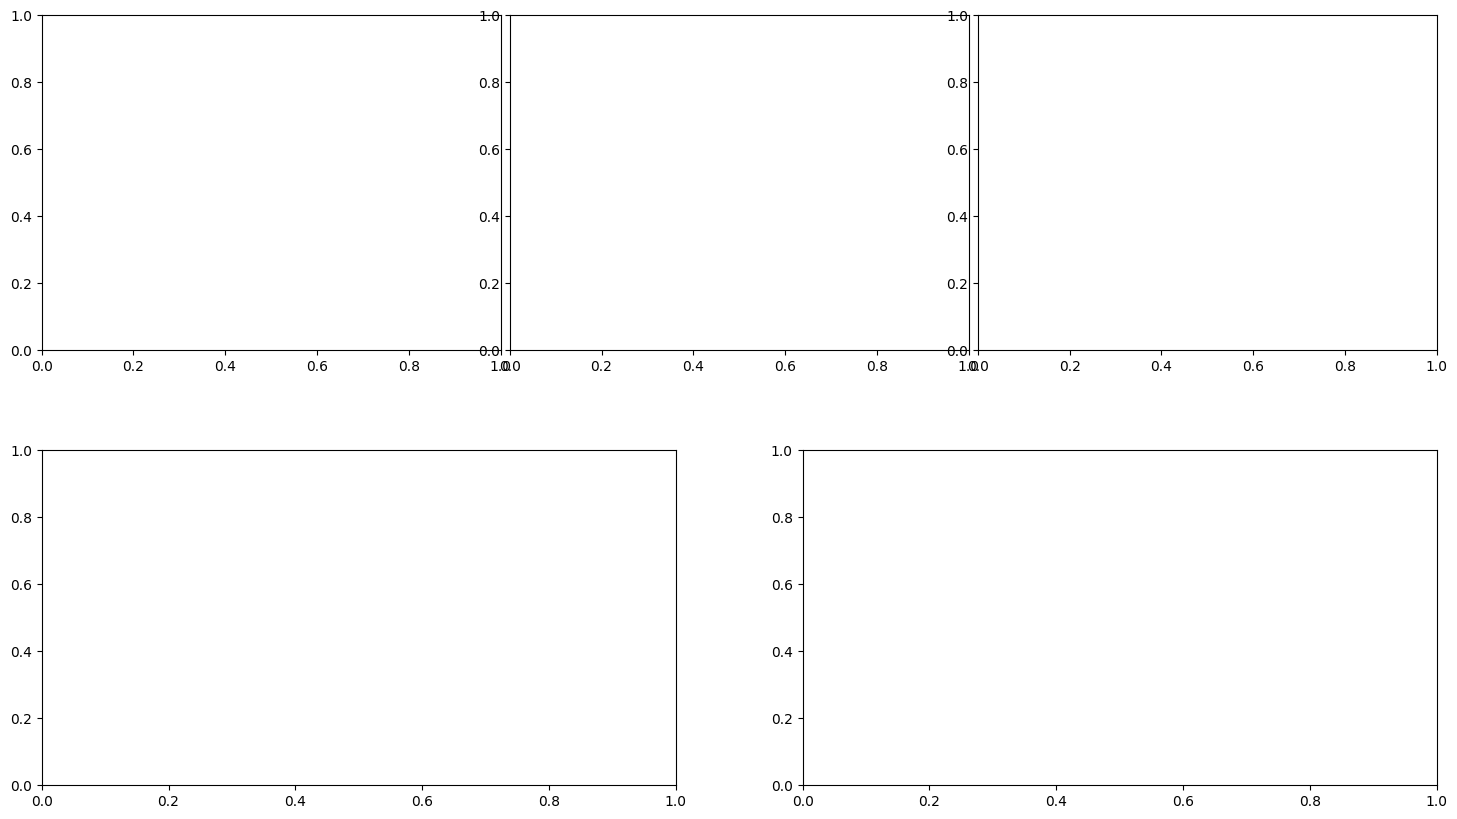

In [ ]:
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(2, 1, height_ratios=[1, 1], hspace=0.3)

gs_top = gs[0].subgridspec(1, 3, wspace=0.02)P
axes = [fig.add_subplot(gs_top[i]) for i in range(3)]

gs_bottom = gs[1].subgridspec(1, 2, wspace=0.2)
ax_timeseries = fig.add_subplot(gs_bottom[0])
ax_extra = fig.add_subplot(gs_bottom[1])

In [32]:
# Pop-Weighted Global Impact Mortality Rate
month_order = [8, 9, 10, 11, 12, 1]
cmap = plt.get_cmap("coolwarm")
colors = {"net": 'gray', "hotonly": mcolors.to_hex(cmap(0.85)), "coldonly": mcolors.to_hex(cmap(0.15))}
ax = ax_timeseries
for hotonly in ["net", "hotonly", "coldonly"]:
    impact = analysis_utils.compute_impact(
        effect,
        socioeconomics,
        ensemble=True,
        baseline_period=baseline_period,
        hotonly=hotonly,
        rate=False,
        age_weight=True,
    )
    da = impact.sum("region").reindex(month=month_order)*100000 / socioeconomics['pop'].sum(dim = 'region').values
    da = da.assign_coords(
        month=range(len(month_order))
    ) 

    da.stack(sample_all=["number", "sample"]).reset_index("sample_all").plot.line(x='month', hue='sample_all', alpha=0.2, linewidth=.2, ax=ax, color=colors[hotonly])
    da.mean(dim=["number", "sample"]).plot(marker="o", ax=ax, label=hotonly, color=colors[hotonly])

ax.axhline(y=0, color="black", linewidth=0.5)
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order)
ax.set_xlabel("month")
ax.set_ylabel("Mortality Rate [deaths/100k]")
ax.legend()
ax.set_title("")

Text(0.5, 1.0, '')

In [33]:
# Maps
for ax, hotonly in zip(axes, ["net", "hotonly", "coldonly"]):
    impact = analysis_utils.compute_impact(
        effect,
        socioeconomics,
        ensemble=False,
        baseline_period=baseline_period,
        hotonly=hotonly,
        rate=True,
        age_weight=True,
    )
    cum_impact = impact.mean(dim="sample").sum("month")
    _polygons_impact = analysis_utils.xarray_to_gpd(cum_impact, _polygons)
    analysis_utils.plot_single(
        _polygons_impact,
        col="age_weighted_impact",
        cm="bwr",
        vmin=-16,
        vmax=16,
        n_colors=10,
        colorbar=False,
        cbar_label="Mortality Rate [deaths/100k]",
        ax=ax,
    )
cmap, norm, sm, ticks, step = analysis_utils.build_colormap(
    _polygons_impact, "age_weighted_impact", cm="bwr", vmin=-16, vmax=16, n_colors=10
)

cbar = fig.colorbar(
    sm,
    ax=axes,
    location="right",
    shrink=0.8,
    ticks=ticks,
    label="Mortality Rate [deaths/100k]",
    fraction=0.025,
    pad=0.02,
)

for ax in axes:
    ax.set_axis_off()

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_

In [34]:
# Boxplot
quartile_labels = ["Low income", "Low-middle income", "Middle-high income", "High income"]
quartile_labels_display = [lbl.replace(" ", "\n", 1) for lbl in quartile_labels]

data_by_category = {}
for hotonly in ["net", "hotonly", "coldonly"]:
    # Mortality Rate
    impact = analysis_utils.compute_impact(
        effect, socioeconomics, ensemble=False,
        baseline_period=baseline_period, hotonly=hotonly,
        rate=True, age_weight=True,
    )
    # Monthly average
    impact_mean = impact.mean(dim="month")
    # Average across forecast and economic uncertainty
    if "number" in impact_mean.dims or "sample" in impact_mean.dims:
        impact_mean = impact_mean.mean(dim=[d for d in ["number", "sample"] if d in impact_mean.dims])
    # Pair impact, gdppc, and pop
    impact_aligned, gdppc_aligned = xr.align(impact_mean, socioeconomics.gdppc, join="inner")
    pop_aligned = socioeconomics.pop.sel(region=impact_aligned.region)

    region_vals = impact_aligned.values

    # Compute Pop-Weighted Quartiles
    sort_idx = np.argsort(gdppc_aligned.values)
    gdppc_sorted = gdppc_aligned.values[sort_idx]
    pop_sorted = pop_aligned.values[sort_idx]

    cum_pop = np.cumsum(pop_sorted)
    cum_pop_frac = cum_pop / cum_pop[-1]

    breakpoints = np.interp([0.25, 0.5, 0.75], cum_pop_frac, gdppc_sorted)
    bin_edges = np.concatenate([[gdppc_sorted[0] - 1], breakpoints, [gdppc_sorted[-1] + 1]])

    quartiles = pd.cut(gdppc_aligned.values, bins=bin_edges, labels=quartile_labels)
    data_by_category[hotonly] = [region_vals[quartiles == q] for q in quartile_labels]

ax = ax_extra
positions = []
box_data = []
group_gap = 1
box_width = 0.6
n_quartiles = 4

for i, category in enumerate(["net", "hotonly", "coldonly"]):
    for j, q_data in enumerate(data_by_category[category]):
        positions.append(i * (n_quartiles + group_gap) + j)
        box_data.append(q_data)

bp = ax.boxplot(
    box_data,
    positions=positions,
    widths=box_width,
    patch_artist=True,
    medianprops=dict(color="black"),
    tick_labels=quartile_labels * 3,
    showfliers=False,
)

for patch, color in zip(bp['boxes'], [colors[c] for c in ["net", "hotonly", "coldonly"] for _ in range(n_quartiles)]):
    patch.set_facecolor(color)

group_centers = [i * (n_quartiles + group_gap) + (n_quartiles - 1) / 2 for i in range(3)]

ax.set_ylim(-5, 5)
ax.set_xticks(positions)
ax.set_xticklabels(quartile_labels_display * 3, fontsize=8, rotation=45, ha="right")

ax.set_ylabel("Mortality Rate [deaths/100k]")
ax.axhline(y=0, color="black", linewidth=0.5)

sec = ax.secondary_xaxis(-0.2)
sec.set_xticks(group_centers)
sec.set_xticklabels(["Net", "Hot", "Cold"])
sec.tick_params(length=0)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_

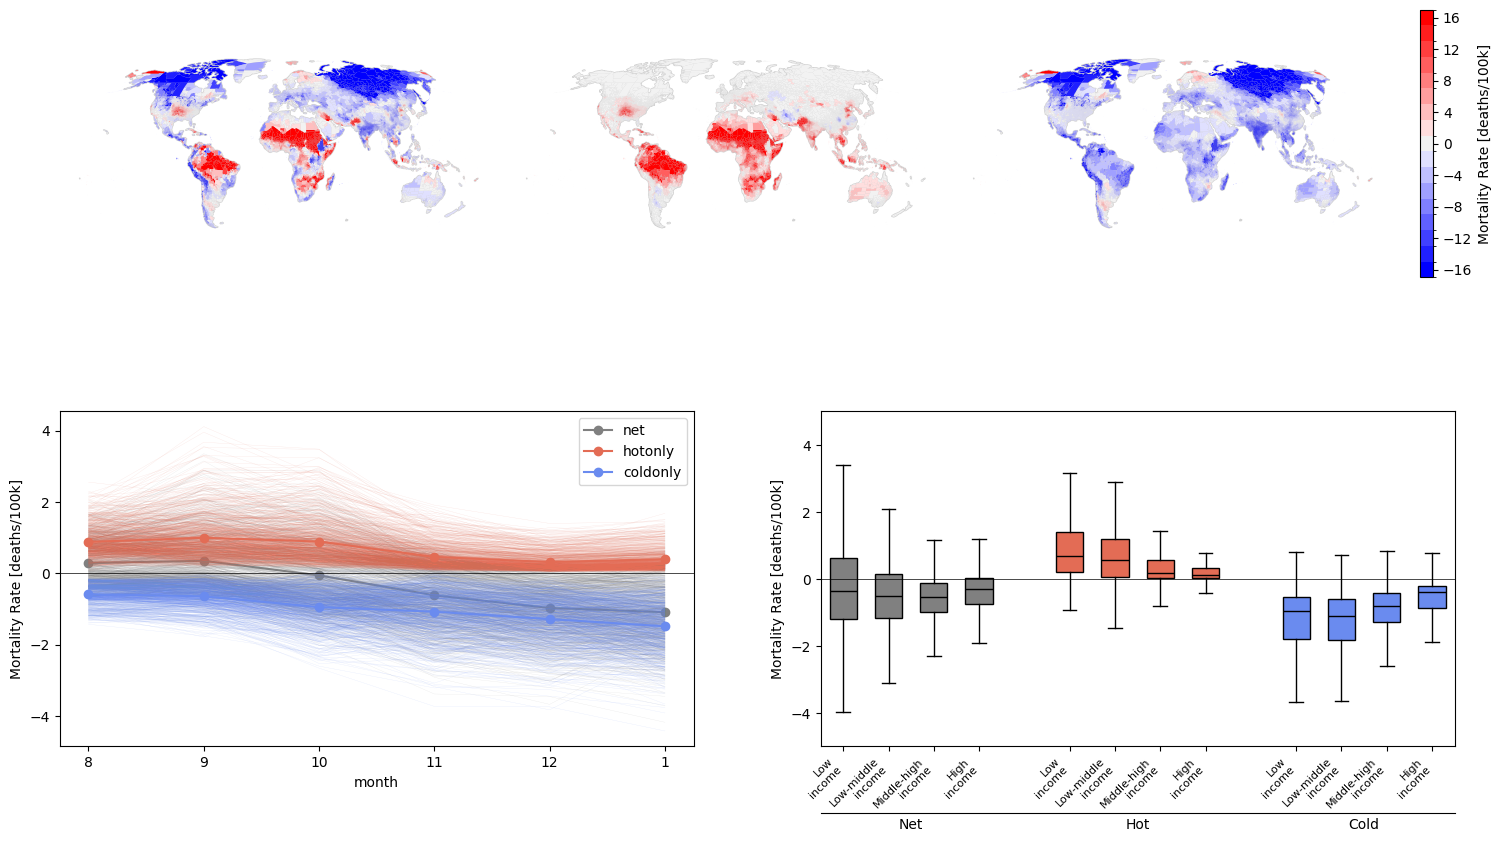

In [35]:
fig

In [36]:
fig.savefig("fig03_2608_cum_rate_2x3.png", dpi=600, bbox_inches="tight")

# Figure A3. 
Average forecast monthly temperature anomaly

In [37]:
## Raw ##
# Raw Forecast/Hindcast
s51 = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_RAW))
forecast = s51.sel(time=slice("2026-08-01", "2027-01-31")).groupby("time.month").mean()
hindcast = (
    s51.sel(time=slice("1996-08-01", "2025-12-31"))
    .groupby("time.month")
    .mean()
    .sel(month=[1, 8, 9, 10, 11, 12])
)

In [38]:
anomaly = forecast["tas"] - hindcast["tas"]
anomaly.name = "forecast_anomaly"

In [39]:
anomaly_ir = isku_utils.grid_to_ir(anomaly.compute(), savefile=None)
_polygons_anomaly = analysis_utils.xarray_to_gpd(
    anomaly_ir.mean(dim="number"), _polygons
)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


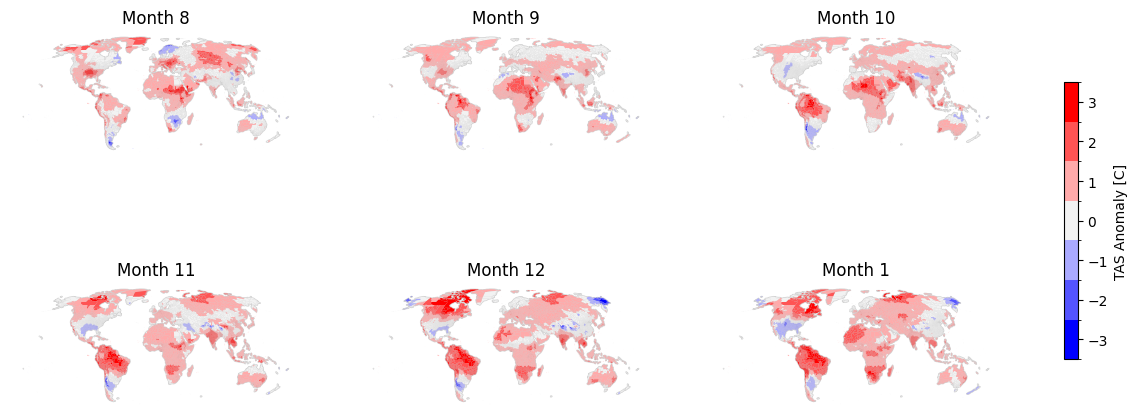

In [40]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly,
    col="value",
    cm="bwr",
    sup_title="",
    cbar_label="TAS Anomaly [C]",
    month_order=[8, 9, 10, 11, 12, 1],
)
fig.savefig("figA3raw_2608_anomaly.png", dpi=600, bbox_inches="tight")

In [41]:
## Corrected ##
era5 = xr.open_zarr(os.path.join(DATA_DIR, ERA5_URI)).sel(
    time=slice("1996-01-01", "2025-12-31")
)
forecast = xr.open_zarr(os.path.join(DATA_DIR, TAS_FORECAST_URI))

In [42]:
anomaly_corr = forecast.mean(dim=["number"]).groupby(
    "time.month"
).mean() - era5.groupby("time.month").mean().sel(month=[8, 9, 10, 11, 12, 1])

In [43]:
# Gridded to Impact Region
anomaly_corr_ir = isku_utils.grid_to_ir(anomaly_corr, savefile=None)
_polygons_anomaly_corr = analysis_utils.xarray_to_gpd(anomaly_corr_ir["tas"], _polygons)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


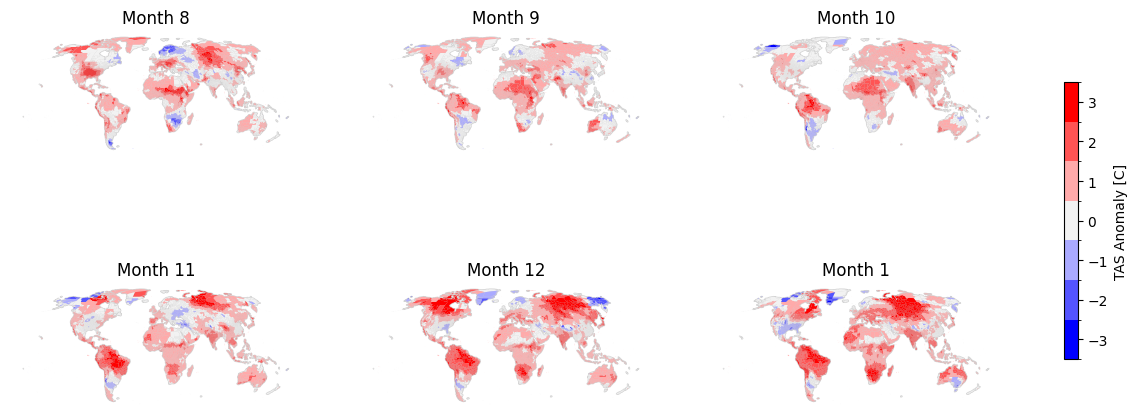

In [44]:
fig = analysis_utils.plot_monthly(
    _polygons_anomaly_corr,
    col="tas",
    cm="bwr",
    sup_title="",
    cbar_label="TAS Anomaly [C]",
    month_order=[8, 9, 10, 11, 12, 1],
)
fig.savefig("figA3era5_2608_anomaly.png", dpi=600, bbox_inches="tight")

# Figure A4. 
Forecast ensemble 10-90 percentile range in temperature by month:

In [45]:
forecast = s51.sel(time=slice("2026-08-01", "2027-01-31")).groupby("time.month").mean()
forecast_var = forecast["tas"].var(dim="number")

In [46]:
# Gridded to Impact Region
forecast_var_ir = isku_utils.grid_to_ir(forecast_var, savefile=None)
_polygons_forecast_var = analysis_utils.xarray_to_gpd(forecast_var_ir, _polygons)

/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py:29: RuntimeWarning: Failed to open Zarr store with consolidated metadata, but successfully read with non-consolidated metadata. This is typically much slower for opening a dataset. To silence this warning, consider:
1. Consolidating metadata in this existing store with zarr.consolidate_metadata().
2. Explicitly setting consolidated=False, to avoid trying to read consolidate metadata, or
3. Explicitly setting consolidated=True, to raise an error in this case instead of falling back to try reading non-consolidated metadata.
  _region_weights = xr.load_dataset(uri)[
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/zarr/core/group.py:3289: ZarrUserWarning: Object at zarr.json:Zone.Identifier is not recognized as a component of a Zarr hierarchy.
  warnings.warn(


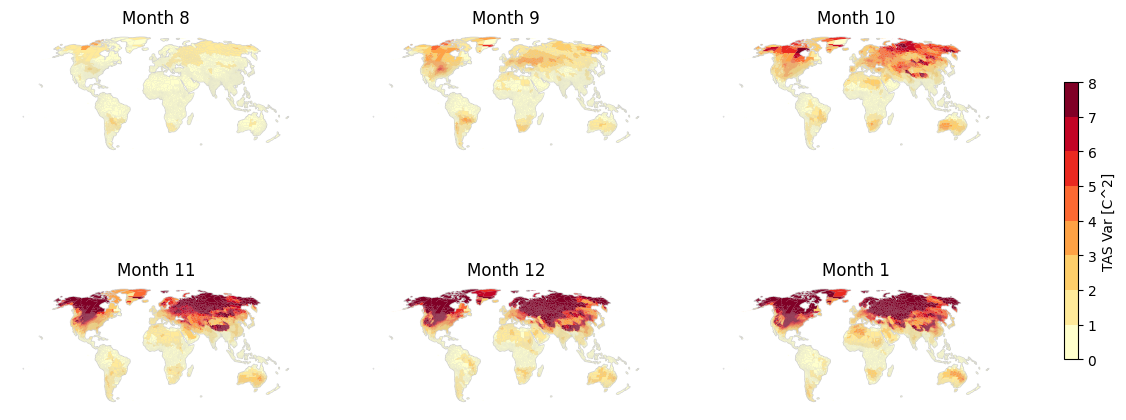

In [47]:
fig = analysis_utils.plot_monthly(
    _polygons_forecast_var,
    col="value",
    cm="YlOrRd",
    vmin=0,
    vmax=8,
    n_colors=10,
    sup_title="",
    cbar_label="TAS Var [C^2]",
    month_order=[8, 9, 10, 11, 12, 1],
)
fig.savefig("figA4_2608_forecast_var.png", dpi=600, bbox_inches="tight")

### Anomaly variance

In [48]:
_polygons_forecast_anomaly_var = analysis_utils.xarray_to_gpd(
    anomaly_ir.var(dim="number"), _polygons
)

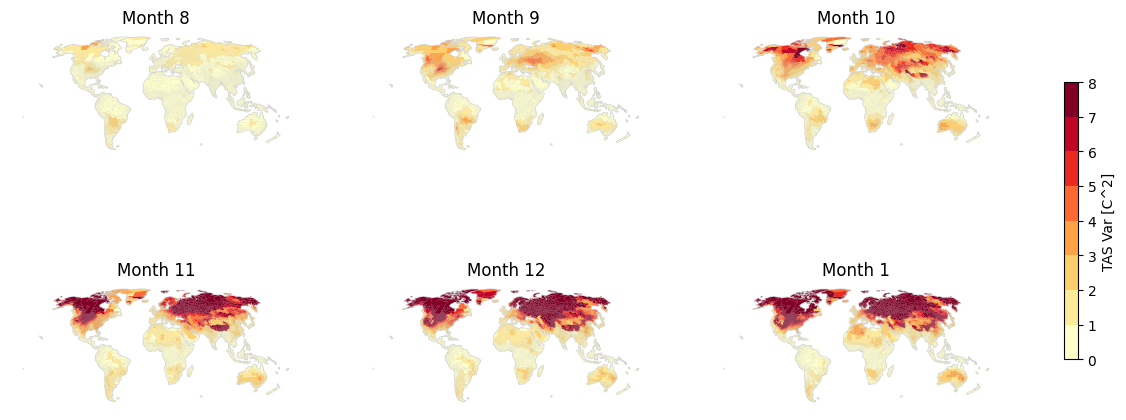

In [49]:
fig = analysis_utils.plot_monthly(
    _polygons_forecast_anomaly_var,
    col="value",
    cm="YlOrRd",
    vmin=0,
    vmax=8,
    n_colors=10,
    sup_title="",
    cbar_label="TAS Var [C^2]",
    month_order=[8, 9, 10, 11, 12, 1],
)
fig.savefig("figA4_2608_forecast_anom_var.png", dpi=600, bbox_inches="tight")

# Figure A6. 
Baseline age-weighted mean mortality rate by month: caption

# Figure A8. 
Change in age-weighted mean mortality rate by month: caption

In [50]:
impact = analysis_utils.compute_impact(
    effect,
    socioeconomics,
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="net",
    rate=True,
    age_weight=True,
)

In [51]:
_polygons_impact = analysis_utils.xarray_to_gpd(
    impact.mean(dim=["number", "sample"]), _polygons
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_

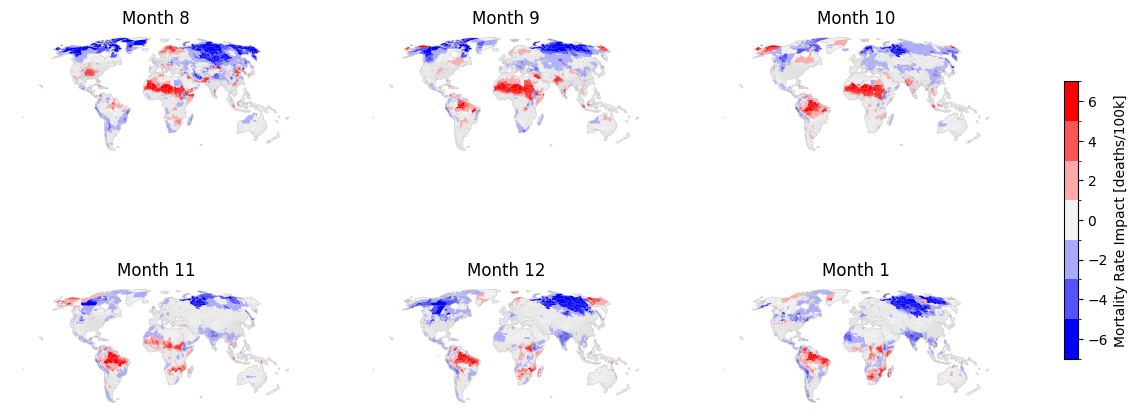

In [52]:
fig = analysis_utils.plot_monthly(
    _polygons_impact,
    col="age_weighted_impact",
    cm="bwr",
    sup_title="",
    cbar_label="Mortality Rate Impact [deaths/100k]",
    month_order=[8, 9, 10, 11, 12, 1],
)
fig.savefig("figA8_2608_monthly_rate_impact.png", dpi=600, bbox_inches="tight")

# Figure A9. 
Forecast uncertainty standard deviation of change in age-weighted mean mortality rate by month: caption

In [53]:
_polygons_impact_std = analysis_utils.xarray_to_gpd(
    impact.std(dim=["number", "sample"]), _polygons
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_spec.py:768: RuntimeWarning: invalid value encountered in divide
  return self.func(*new_argspec)
/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/_task_

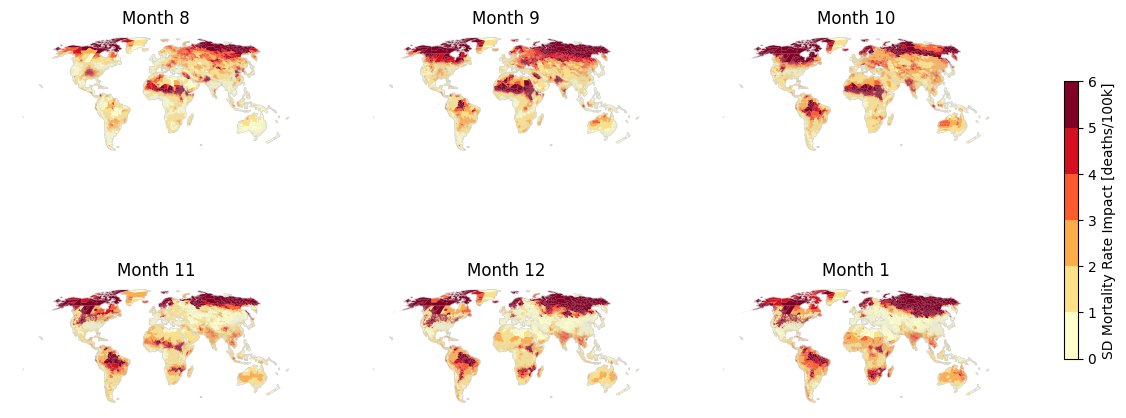

In [54]:
fig = analysis_utils.plot_monthly(
    _polygons_impact_std,
    col="age_weighted_impact",
    cm="YlOrRd",
    vmin=0,
    vmax=6,
    sup_title="",
    cbar_label="SD Mortality Rate Impact [deaths/100k]",
    month_order=[8, 9, 10, 11, 12, 1],
)
fig.savefig("figA9_2608_monthly_rate_impact_sd.png", dpi=600, bbox_inches="tight")